In [ ]:
# ==========================================
# URDU HANDWRITTEN CHARACTER RECOGNITION (STRICT LABELS SYNC)
# ==========================================

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report, accuracy_score

# --- CONFIGURATION ---
train_data_dir = "Dataset"
img_width, img_height = 64, 64
batch_size = 16
epochs = 15
SEED = 42

# ==========================================
# PART 1: UNIFIED DATA LIFTCYCLE
# ==========================================

shared_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=False,
    validation_split=0.2
)

print("⚡ Training Dataset load ho raha hai...")
train_generator = shared_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

print("⚡ Validation Dataset load ho raha hai...")
validation_generator = shared_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,  # CRITICAL: Keeping it completely static for exact index evaluation
    seed=SEED
)

num_classes = len(train_generator.class_indices)
print(f"\n✅ Total detected character classes: {num_classes}")

# ==========================================
# PART 2: LIGHTWEIGHT ROBUST CNN
# ==========================================

print("\n🏗️ Building Optimized CNN Model...")
cnn_model = Sequential([
    Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=(img_width, img_height, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("🚀 Training CNN Model...")
cnn_history = cnn_model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator
)

# ==========================================
# PART 3: RE-CHECKED DETERMINISTIC EVALUATION
# ==========================================

# Pulling exact chronological states from the validation engine
validation_generator.reset() # Reset pointer to prevent skipping slices
y_true = validation_generator.classes
class_names = list(validation_generator.class_indices.keys())

print("\n=======================================================")
print("           📊 CNN MODEL EVALUATION METRICS              ")
print("=======================================================")
cnn_predictions = cnn_model.predict(validation_generator, steps=len(validation_generator), verbose=1)
cnn_y_pred = np.argmax(cnn_predictions, axis=1)

print(f"\nVerified CNN Validation Accuracy: {accuracy_score(y_true, cnn_y_pred)*100:.2f}%")
print("\nCNN Classification Report:")
print(classification_report(y_true, cnn_y_pred, target_names=class_names, zero_division=0))

⚡ Training Dataset load ho raha hai...
Found 592 images belonging to 37 classes.
⚡ Validation Dataset load ho raha hai...
Found 147 images belonging to 37 classes.

✅ Total detected character classes: 37

🏗️ Building Optimized CNN Model...
🚀 Training CNN Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 202ms/step - accuracy: 0.0186 - loss: 3.6965 - val_accuracy: 0.0340 - val_loss: 3.6103
Epoch 2/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - accuracy: 0.0270 - loss: 3.6124 - val_accuracy: 0.0408 - val_loss: 3.6100
Epoch 3/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - accuracy: 0.0236 - loss: 3.6104 - val_accuracy: 0.0340 - val_loss: 3.6087
Epoch 4/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - accuracy: 0.0473 - loss: 3.6060 - val_accuracy: 0.0816 - val_loss: 3.6041
Epoch 5/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.0507 - loss: 3.5968 - val_accuracy: 0.0884 - val_loss: 3.5839
Epoch 6/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - accuracy: 0.0642 - loss: 3.5440 - val_accuracy: 0.1905 - val_loss: 3.4686
Epoch 7/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - accuracy: 0.1030 - loss: 3.3439 - val_accuracy: 0.2585 - val_loss: 3.1530
Epoch 8/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 152ms/step - accuracy: 0.1909 - loss: 2.9701 - val_accuracy: 0

📁 Apni testing image (.jpg ya .png) upload karein...


Saving color_0_7069.jpg to color_0_7069.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


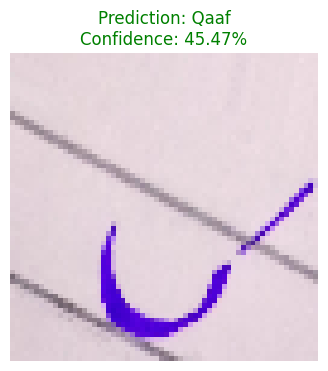


🎯 Result: Model ko 45.47% lagta hai ke yeh 'Qaaf' likha hua hai.


In [ ]:
# ==========================================
# TEST YOUR TRAINED MODEL WITH EXTERNAL IMAGES
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.preprocessing import image

# 1. Image upload karne ka widget open hoga
print("📁 Apni testing image (.jpg ya .png) upload karein...")
uploaded = files.upload()

for filename in uploaded.keys():
    # 2. Image ko model ke dimensions (64x64) ke mutabiq load aur preprocess karna
    img_path = filename
    img = image.load_img(img_path, target_size=(64, 64))

    # Image ko array mein convert karna aur values ko normalize (1./255) karna
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # Batch dimension add karna (1, 64, 64, 3)

    # 3. Model se predict karwana
    predictions = cnn_model.predict(img_array)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    confidence_score = np.max(predictions) * 100

    # 4. Class names ko map karna (alphabetical order automatic maps from generator)
    class_indices = train_generator.class_indices
    inv_class_indices = {v: k for k, v in class_indices.items()}
    predicted_class_name = inv_class_indices[predicted_class_index]

    # Clean character name (remove '_augmented' from folder name for clean view)
    display_name = predicted_class_name.replace('_augmented', '')

    # 5. Result ko plot aur display karna
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Prediction: {display_name}\nConfidence: {confidence_score:.2f}%", fontsize=12, color='green')
    plt.axis('off')
    plt.show()

    print(f"\n🎯 Result: Model ko {confidence_score:.2f}% lagta hai ke yeh '{display_name}' likha hua hai.")

In [ ]:
!unzip -q Dataset.zip